# CAMM Hackathon 15: Vector Field Problem - NanoLithography


- In scanning-probe nanolithography, a biased AFM tip can switch ferroelectric polarization not only through voltage amplitude, but also through the geometry of its motion.
- The tip trajectory creates an effective in-plane electric-field pattern that can guide local switching and stabilize designed domain configurations.

Examples:

[Vasudevan, R.; et al. On-demand nanoengineering of in-plane ferroelectric topologies](https://www.nature.com/articles/s41565-024-01792-1)

[Vasudevan R., et al. Deterministic arbitrary switching of polarization in a ferroelectric thin film](https://www.nature.com/articles/ncomms5971)

####Today, we are going to focus on **designing lithography trajectories** that generate target electric-field patterns in a minimal ferroelectric model.



We consider a sharp, electrically biased probe moving across a ferroelectric surface. As the probe moves, it can locally switch the material’s polarization, making the lithography trajectory itself part of the design problem.

Two key assumptions define the simplified model:

- A moving probe creates an effective trailing in-plane field in its wake. The local polarization tends to align with the direction of probe motion.
- At each moment, you control two main parameters: the probe position or path, and the applied voltage (V). In a more complete model, the probe speed could also be included, since it affects domain-growth dynamics and therefore the final written pattern.

In this simplified challenge, the effective writing field is approximated as


$\;\mathbf{E}_{\text{eff}} = V\cdot\hat{\mathbf t}\;$

where ($\hat{\mathbf t}$) is the local travel direction of the probe. The direction of motion sets the field orientation, the voltage sets its sign and strength, and larger ($|V|$) switches a wider region of the material.

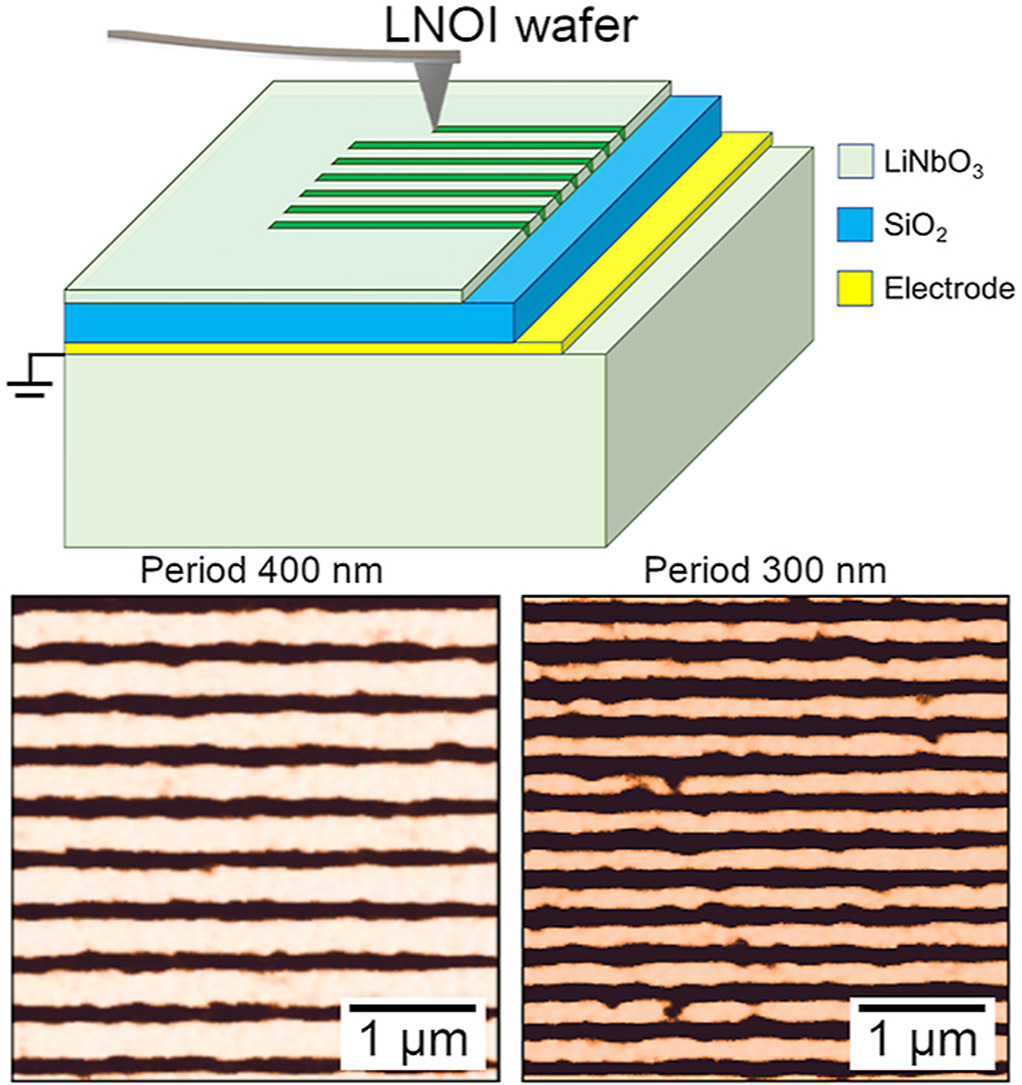

*https://www.sciencedirect.com/science/article/pii/S0272884221025785

### A quick physics intuition

A biased probe writes an in-plane field in its wake; the direction of motion sets the field orientation and the voltage sets its sign and strength.

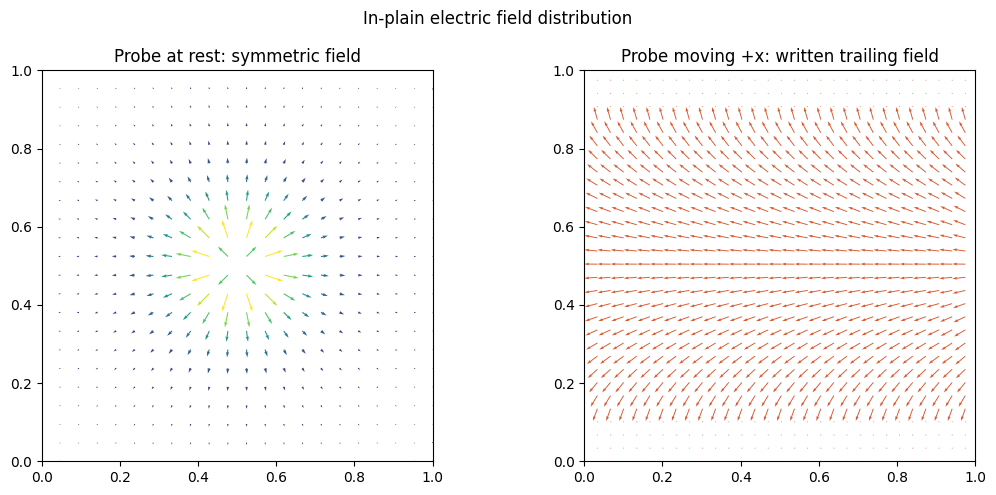

In [1]:
import numpy as np, matplotlib.pyplot as plt

h = 0.10                                   # pen (point-charge) height above the surface
def E(X, Y, xc, yc):                       # in-plane surface field from a charge at (xc, yc, h)
    dx, dy = X - xc, Y - yc
    r3 = (dx*dx + dy*dy + h*h)**1.5
    return dx/r3, dy/r3

fig, ax = plt.subplots(1, 2, figsize=(11, 5))

# --- AT REST: charge sits at the centre -> symmetric field, no chosen direction ---
g = np.linspace(0, 1, 22); X, Y = np.meshgrid(g, g)
Ex, Ey = E(X, Y, 0.5, 0.5)
ax[0].quiver(X, Y, Ex, Ey, np.hypot(Ex, Ey), cmap="viridis", scale=800)
ax[0].set_title("Probe at rest: symmetric field")

# --- MOVING +x: the spot that switches LAST is written (overwrite) -> a trailing wake ---
gg = np.linspace(0, 1, 120); Xs, Ys = np.meshgrid(gg, gg)
Px = np.zeros_like(Xs); Py = np.zeros_like(Xs); Ec = 6.0     # switching threshold
for xc in np.linspace(-0.25, 1.25, 300):                     # pen sweeps left -> right
    ex, ey = E(Xs, Ys, xc, 0.5); m = np.hypot(ex, ey); sw = m > Ec
    Px[sw], Py[sw] = ex[sw]/m[sw], ey[sw]/m[sw]              # last write wins
s = slice(None, None, 4)
ax[1].quiver(Xs[s, s], Ys[s, s], Px[s, s], Py[s, s], color="#D85A30", scale=30)
ax[1].set_title("Probe moving +x: written trailing field")

for a in ax: a.set_aspect("equal"); a.set_xlim(0, 1); a.set_ylim(0, 1)
plt.suptitle('In-plain electric field distribution')
plt.tight_layout(); plt.show()

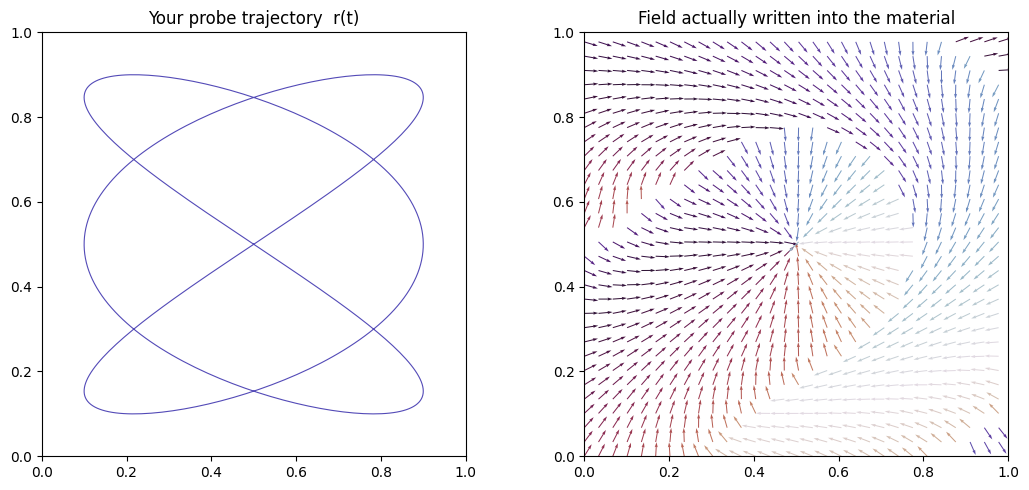

In [2]:
import numpy as np, matplotlib.pyplot as plt

h, Ec = 0.06, 12.0                         # pen height above surface, switching threshold
def Efield(X, Y, xc, yc, V):               # in-plane field of the charged pen (V scales it)
    dx, dy = X - xc, Y - yc; r3 = (dx*dx + dy*dy + h*h)**1.5
    return V*dx/r3, V*dy/r3

# ---- YOUR design: path r(t) + voltage V(t)  (sign of V = direction, |V| = brush width) ----
t = np.linspace(0, 1, 500)
def path(t): return 0.5 + 0.40*np.sin(2*np.pi*3*t), 0.5 + 0.40*np.sin(2*np.pi*2*t)
def volt(t): return np.where(t < 0.5, 1.0, -1.0)        # e.g. flip the sign halfway
xc, yc = path(t); V = volt(t)

# ---- write into the film: move the pen; the last above-threshold field wins (overwrite) ----
g = np.linspace(0, 1, 90); X, Y = np.meshgrid(g, g)
Px = np.full_like(X, np.nan); Py = np.full_like(X, np.nan)
for i in range(len(t)):
    ex, ey = Efield(X, Y, xc[i], yc[i], V[i]); m = np.hypot(ex, ey); sw = m > Ec
    Px[sw], Py[sw] = ex[sw]/m[sw], ey[sw]/m[sw]

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].plot(xc, yc, lw=.8, c="#534AB7"); ax[0].set_title("Your probe trajectory  r(t)")
s = slice(None, None, 3)
ax[1].quiver(X[s,s], Y[s,s], Px[s,s], Py[s,s], np.arctan2(Py, Px)[s,s],
             cmap="twilight", scale=30)
ax[1].set_title("Field actually written into the material")
for a in ax: a.set_aspect("equal"); a.set_xlim(0, 1); a.set_ylim(0, 1)
plt.tight_layout(); plt.show()

### Possible Problems to be Solves


#### **1. Prompt-to-trajectory generation**

Develop a system that converts a user request into a lithography trajectory.
For example, given prompts such as “write a vortex,” “create a centre-divergent pattern,” or “make a dense array of flux-closure-like structures,” the system should generate a probe path (x(t), y(t)) and voltage profile (V(t)).

#### 2. **Forward simulation of the written pattern (high complexity)**

Build a simplified model that predicts the resulting in-plane polarization or electric-field pattern from a proposed trajectory.
The model does not need to describe the full probe–sample physics, but should capture the main idea: probe motion defines the local field direction, voltage defines switching strength and sign, and material response can be approximated through simple parameters such as permittivity or switching width.

#### 3. **Trajectory optimization**

Given a target structure type and constraints, optimize the trajectory parameters.
Possible objectives include improving pattern quality, increasing feature density, reducing writing time, minimizing voltage exposure, or matching a desired domain size.

#### 4. **Inverse design from a target pattern**

Solve the inverse problem: given a desired vector-field image/pattern, generate a trajectory that could approximately write it.


The solution can be implemented either as an agentic system or as any other algorithmic approach.

# 2. LLM-based vector-field design from a prompt

A natural-language request is converted into a **target vector field** `P_target` (the ground truth we want to write). The LLM only selects field *primitives* and their parameters; Python renders them into a deterministic 128x128x2 field plus a target mask.

In [3]:
# Set your OpenAI API key for the LLM field design step (no key is stored in the notebook).
import os, getpass
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter OPENAI_API_KEY: ")

Enter OPENAI_API_KEY: ··········


In [4]:
#@title LLM_estimator

# LLM picks a few vector-field PRIMITIVES (vortex, radial, spiral, ...) from the prompt;
# Python then renders them deterministically into a 128x128x2 target field + mask.

# ============================================================
# LLM-based prompt -> primitive program -> 128x128 vector field
# ============================================================
#
# Install if needed:
#     pip install openai pydantic numpy matplotlib
#
# Set API key:
#     export OPENAI_API_KEY="..."
#
# Main function:
#     P_target, mask, program = prompt_to_primitive_vector_field(prompt)
#
# Output:
#     P_target.shape == (128, 128, 2)
#     P_target[..., 0] = Px
#     P_target[..., 1] = Py
#
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from typing import Literal
from pydantic import BaseModel, Field
from openai import OpenAI


# ============================================================
# 1. Primitive schema
# ============================================================

PrimitiveName = Literal[
    "uniform",
    "vortex",
    "radial",
    "spiral",
    "saddle",
    "stripe",
    "domain_wall",
    "ring_vortex",
    "ring_radial",
    "dipole_pair",
    "vortex_pair",
    "flux_closure",
    "four_domain_closure",
    "source_sink_line",
    "vortex_chain",
]

MaskShape = Literal[
    "full",
    "ellipse",
    "box",
    "annulus",
]


class PrimitiveCall(BaseModel):
    """
    One vector-field primitive selected by the LLM.
    """

    name: PrimitiveName = Field(
        description="Name of the vector-field primitive."
    )

    # Position and size, in microns
    center_x_um: float = Field(default=2.5, description="Center x-coordinate in microns.")
    center_y_um: float = Field(default=2.5, description="Center y-coordinate in microns.")
    radius_x_um: float = Field(default=1.0, description="Horizontal size in microns.")
    radius_y_um: float = Field(default=1.0, description="Vertical size in microns.")

    # For annular primitives
    inner_radius_um: float = Field(default=0.4, description="Inner radius for ring-like primitives.")

    # Orientation
    angle_deg: float = Field(
        default=0.0,
        description="Rotation angle in degrees. For uniform fields, this is the vector direction."
    )

    # Relative strength
    weight: float = Field(
        default=1.0,
        description="Relative strength of this primitive. Usually between 0.2 and 2."
    )

    # Region where primitive is active
    mask_shape: MaskShape = Field(default="ellipse")
    softness: float = Field(
        default=0.08,
        description="Softness of primitive boundary. Typical range: 0.03 to 0.2."
    )

    # Vortex / spiral / radial options
    chirality: Literal["cw", "ccw"] = Field(default="ccw")
    radial_mode: Literal["divergent", "convergent"] = Field(default="divergent")
    spiral_mix: float = Field(
        default=0.5,
        description="For spiral primitives: 0 = purely radial, 1 = purely vortex."
    )

    # Stripe / domain-wall options
    period_um: float = Field(default=0.5, description="Stripe period in microns.")
    wall_width_um: float = Field(default=0.08, description="Domain-wall transition width in microns.")

    # Pair / chain options
    separation_um: float = Field(default=1.0, description="Separation between paired objects in microns.")
    n_repeats: int = Field(default=3, description="Number of repeated motifs for chain-like primitives.")


class FieldProgram(BaseModel):
    """
    Full vector-field program returned by the LLM.
    """

    description: str = Field(description="Brief interpretation of the user request.")

    width_um: float = Field(default=5.0, description="Field-of-view width in microns.")
    height_um: float = Field(default=5.0, description="Field-of-view height in microns.")

    background_angle_deg: float = Field(default=0.0)
    background_weight: float = Field(
        default=0.0,
        description="Weak background field strength. Use 0 for no background."
    )

    primitives: list[PrimitiveCall] = Field(
        description="List of vector-field primitives that together define the target pattern."
    )


# ============================================================
# 2. Primitive catalogue for the LLM
# ============================================================

PRIMITIVE_CATALOGUE = """
Available vector-field primitives:

1. uniform
   Constant vector direction inside a selected region.
   Useful for uniformly poled domains.

2. vortex
   Circulating field around a center.
   chirality='cw' for clockwise, chirality='ccw' for counterclockwise.

3. radial
   Center-divergent or center-convergent field.
   radial_mode='divergent' for outward.
   radial_mode='convergent' for inward.

4. spiral
   Mixture of radial and vortex field.
   spiral_mix=0 gives radial.
   spiral_mix=1 gives vortex.
   Intermediate values produce spiral-like fields.

5. saddle
   Hyperbolic vector field.
   Useful for quadrupole-like or domain-wall-junction-like patterns.

6. stripe
   Alternating stripe-like polarization.
   period_um controls stripe period.
   angle_deg controls stripe orientation.

7. domain_wall
   Two domains separated by a soft wall.
   angle_deg controls wall orientation.

8. ring_vortex
   Circulating field restricted to a ring.

9. ring_radial
   Radial field restricted to a ring.

10. dipole_pair
   Pair of one divergent and one convergent radial object.

11. vortex_pair
   Pair of vortices with opposite chirality.

12. flux_closure
   Compact flux-closure-like circulating field.

13. four_domain_closure
   Four-domain closure-like object around one center.

14. source_sink_line
   Chain-like source-to-sink radial pattern.

15. vortex_chain
   Several vortices placed along a line.

Mask shapes:
- full: primitive applies to the full image.
- ellipse: soft elliptical region.
- box: soft rectangular region.
- annulus: ring-like region.

General rules:
- Field of view is 5 x 5 microns unless the user says otherwise.
- Use arbitrary centers, sizes, and angles.
- Do not force square arrays unless the user explicitly asks for a square array.
- Prefer 1 to 12 primitives.
- For diagonal arrangements, use multiple primitives with different centers.
- For flower-like structures, combine spiral, vortex, radial, and/or flux_closure primitives.
"""


# ============================================================
# 3. LLM call: prompt -> primitive program
# ============================================================

def llm_prompt_to_program(
    prompt: str,
    model: str = "gpt-4o-mini",
    width_um: float = 5.0,
    height_um: float = 5.0,
) -> FieldProgram:
    """
    Convert natural-language prompt into a primitive-based vector-field program.

    Important:
    The LLM proposes primitives, but the field of view and basic geometry
    are corrected later by sanitize_program().
    """

    if "OPENAI_API_KEY" not in os.environ:
        raise RuntimeError("OPENAI_API_KEY is not set.")

    client = OpenAI()

    system_prompt = f"""
You are a scientific planning model for ferroelectric nanolithography.

Your task:
Convert the user's request into a vector-field program made from primitives.

Strict geometry rules:
- The field of view is fixed: width_um={width_um}, height_um={height_um}.
- Do not change width_um or height_um.
- Coordinates are in microns.
- The center of the image is ({width_um / 2}, {height_um / 2}).
- If the user says "center", "middle", or does not specify a location, place the main primitive at the image center.
- Do not place primitives at the boundary or corner unless the user explicitly asks for it.
- For a single vortex, use one vortex primitive centered near the image center.
- For a single radial/convergent/divergent pattern, use one radial primitive centered near the image center.
- For arrays or chains, use multiple primitives distributed inside the field of view.
- Do not make the primitive larger than the entire field of view unless the user asks for a full-field pattern.
- For vortices, radial patterns, spirals, and flux-closure objects, use mask_shape="ellipse" unless a ring is requested.
- Prefer radius_x_um and radius_y_um between 0.8 and 2.2 for a 5 x 5 micron field.

Pattern rules:
- For "clockwise", use chirality="cw".
- For "counterclockwise", use chirality="ccw".
- For "inward" or "center-convergent", use radial_mode="convergent".
- For "outward" or "center-divergent", use radial_mode="divergent".
- Prefer 1 to 12 primitives.
- Do not output raw 128x128 arrays.

Available primitives:
{PRIMITIVE_CATALOGUE}
"""

    response = client.responses.parse(
        model=model,
        input=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt},
        ],
        text_format=FieldProgram,
    )

    program = response.output_parsed

    # Critical repair step
    program = sanitize_program(
        program,
        prompt=prompt,
        width_um=width_um,
        height_um=height_um,
    )

    return program


# ============================================================
# 4. Utility functions
# ============================================================

def clamp_program(program: FieldProgram) -> FieldProgram:
    """
    Clamp numerical values to safe ranges.
    This protects the renderer if the LLM proposes extreme parameters.
    """

    program.width_um = float(np.clip(program.width_um, 1.0, 20.0))
    program.height_um = float(np.clip(program.height_um, 1.0, 20.0))
    program.background_weight = float(np.clip(program.background_weight, 0.0, 1.0))

    for p in program.primitives:
        p.center_x_um = float(np.clip(p.center_x_um, 0.0, program.width_um))
        p.center_y_um = float(np.clip(p.center_y_um, 0.0, program.height_um))

        p.radius_x_um = float(np.clip(p.radius_x_um, 0.03, program.width_um))
        p.radius_y_um = float(np.clip(p.radius_y_um, 0.03, program.height_um))

        p.inner_radius_um = float(np.clip(p.inner_radius_um, 0.0, max(program.width_um, program.height_um)))
        p.softness = float(np.clip(p.softness, 0.01, 0.5))

        p.weight = float(np.clip(p.weight, -5.0, 5.0))
        p.spiral_mix = float(np.clip(p.spiral_mix, 0.0, 1.0))

        p.period_um = float(np.clip(p.period_um, 0.03, max(program.width_um, program.height_um)))
        p.wall_width_um = float(np.clip(p.wall_width_um, 0.01, 1.0))
        p.separation_um = float(np.clip(p.separation_um, 0.05, max(program.width_um, program.height_um)))
        p.n_repeats = int(np.clip(p.n_repeats, 1, 12))

    return program


def make_grid(nx=128, ny=128, width_um=5.0, height_um=5.0):
    xs = np.linspace(0, width_um, nx)
    ys = np.linspace(0, height_um, ny)
    X, Y = np.meshgrid(xs, ys)
    return X, Y


def normalize_field(P, eps=1e-12):
    mag = np.linalg.norm(P, axis=-1, keepdims=True)
    return P / (mag + eps)


def rotate_xy(x, y, angle_deg):
    theta = np.deg2rad(angle_deg)
    c = np.cos(theta)
    s = np.sin(theta)

    xr = c * x + s * y
    yr = -s * x + c * y

    return xr, yr


def rotate_vectors(vx, vy, angle_deg):
    theta = np.deg2rad(angle_deg)
    c = np.cos(theta)
    s = np.sin(theta)

    vxr = c * vx - s * vy
    vyr = s * vx + c * vy

    return vxr, vyr


def primitive_mask(X, Y, p: PrimitiveCall):
    """
    Smooth spatial mask for one primitive.
    """

    dx = X - p.center_x_um
    dy = Y - p.center_y_um

    xr, yr = rotate_xy(dx, dy, p.angle_deg)

    if p.mask_shape == "full":
        return np.ones_like(X)

    if p.mask_shape == "ellipse":
        rho = np.sqrt((xr / p.radius_x_um) ** 2 + (yr / p.radius_y_um) ** 2)
        return 1.0 / (1.0 + np.exp((rho - 1.0) / p.softness))

    if p.mask_shape == "box":
        sx = np.abs(xr) / p.radius_x_um
        sy = np.abs(yr) / p.radius_y_um
        rho = np.maximum(sx, sy)
        return 1.0 / (1.0 + np.exp((rho - 1.0) / p.softness))

    if p.mask_shape == "annulus":
        r = np.sqrt(dx**2 + dy**2)
        outer = 1.0 / (1.0 + np.exp((r - p.radius_x_um) / p.softness))
        inner = 1.0 / (1.0 + np.exp((p.inner_radius_um - r) / p.softness))
        return outer * inner

    raise ValueError(f"Unknown mask shape: {p.mask_shape}")


def suppress_core(X, Y, center_x, center_y, core_radius_um=0.08):
    """
    Suppress singularity near vortex/radial centers.
    """
    r = np.sqrt((X - center_x) ** 2 + (Y - center_y) ** 2)
    return 1.0 - np.exp(-(r / core_radius_um) ** 2)


def base_vortex(X, Y, center_x, center_y, chirality):
    dx = X - center_x
    dy = Y - center_y
    r = np.sqrt(dx**2 + dy**2) + 1e-12

    if chirality == "ccw":
        Px = -dy / r
        Py = dx / r
    else:
        Px = dy / r
        Py = -dx / r

    return Px, Py


def base_radial(X, Y, center_x, center_y, mode):
    dx = X - center_x
    dy = Y - center_y
    r = np.sqrt(dx**2 + dy**2) + 1e-12

    Px = dx / r
    Py = dy / r

    if mode == "convergent":
        Px = -Px
        Py = -Py

    return Px, Py


def base_uniform(X, Y, angle_deg):
    theta = np.deg2rad(angle_deg)
    Px = np.cos(theta) * np.ones_like(X)
    Py = np.sin(theta) * np.ones_like(Y)
    return Px, Py


# ============================================================
# 5. Primitive renderer
# ============================================================

def render_primitive(X, Y, p: PrimitiveCall):
    """
    Render one primitive into:
        P_component: array, shape (ny, nx, 2)
        M_component: array, shape (ny, nx)
    """

    mask = primitive_mask(X, Y, p)

    dx = X - p.center_x_um
    dy = Y - p.center_y_um

    if p.name == "uniform":
        Px, Py = base_uniform(X, Y, p.angle_deg)

    elif p.name == "vortex":
        Px, Py = base_vortex(X, Y, p.center_x_um, p.center_y_um, p.chirality)
        mask *= suppress_core(X, Y, p.center_x_um, p.center_y_um)

    elif p.name == "radial":
        Px, Py = base_radial(X, Y, p.center_x_um, p.center_y_um, p.radial_mode)
        mask *= suppress_core(X, Y, p.center_x_um, p.center_y_um)

    elif p.name == "spiral":
        Rx, Ry = base_radial(X, Y, p.center_x_um, p.center_y_um, p.radial_mode)
        Vx, Vy = base_vortex(X, Y, p.center_x_um, p.center_y_um, p.chirality)

        a = p.spiral_mix
        Px = (1 - a) * Rx + a * Vx
        Py = (1 - a) * Ry + a * Vy

        mask *= suppress_core(X, Y, p.center_x_um, p.center_y_um)

    elif p.name == "saddle":
        xr, yr = rotate_xy(dx, dy, p.angle_deg)

        vx_local = xr
        vy_local = -yr

        norm = np.sqrt(vx_local**2 + vy_local**2) + 1e-12
        vx_local = vx_local / norm
        vy_local = vy_local / norm

        Px, Py = rotate_vectors(vx_local, vy_local, p.angle_deg)
        mask *= suppress_core(X, Y, p.center_x_um, p.center_y_um)

    elif p.name == "stripe":
        xr, yr = rotate_xy(dx, dy, p.angle_deg)

        phase = np.sin(2 * np.pi * xr / p.period_um)
        sign = np.tanh(phase / 0.15)

        theta = np.deg2rad(p.angle_deg + 90)
        Px = sign * np.cos(theta)
        Py = sign * np.sin(theta)

    elif p.name == "domain_wall":
        xr, yr = rotate_xy(dx, dy, p.angle_deg)

        sign = np.tanh(yr / p.wall_width_um)

        theta = np.deg2rad(p.angle_deg)
        Px = sign * np.cos(theta)
        Py = sign * np.sin(theta)

    elif p.name == "ring_vortex":
        ring = p.model_copy(update={"mask_shape": "annulus"})
        mask = primitive_mask(X, Y, ring)
        Px, Py = base_vortex(X, Y, p.center_x_um, p.center_y_um, p.chirality)

    elif p.name == "ring_radial":
        ring = p.model_copy(update={"mask_shape": "annulus"})
        mask = primitive_mask(X, Y, ring)
        Px, Py = base_radial(X, Y, p.center_x_um, p.center_y_um, p.radial_mode)

    elif p.name == "dipole_pair":
        theta = np.deg2rad(p.angle_deg)
        sx = 0.5 * p.separation_um * np.cos(theta)
        sy = 0.5 * p.separation_um * np.sin(theta)

        Px1, Py1 = base_radial(
            X, Y,
            p.center_x_um - sx,
            p.center_y_um - sy,
            "divergent",
        )

        Px2, Py2 = base_radial(
            X, Y,
            p.center_x_um + sx,
            p.center_y_um + sy,
            "convergent",
        )

        Px = Px1 + Px2
        Py = Py1 + Py2

        core1 = suppress_core(X, Y, p.center_x_um - sx, p.center_y_um - sy)
        core2 = suppress_core(X, Y, p.center_x_um + sx, p.center_y_um + sy)
        mask *= core1 * core2

    elif p.name == "vortex_pair":
        theta = np.deg2rad(p.angle_deg)
        sx = 0.5 * p.separation_um * np.cos(theta)
        sy = 0.5 * p.separation_um * np.sin(theta)

        chir1 = p.chirality
        chir2 = "cw" if chir1 == "ccw" else "ccw"

        Px1, Py1 = base_vortex(
            X, Y,
            p.center_x_um - sx,
            p.center_y_um - sy,
            chir1,
        )

        Px2, Py2 = base_vortex(
            X, Y,
            p.center_x_um + sx,
            p.center_y_um + sy,
            chir2,
        )

        Px = Px1 + Px2
        Py = Py1 + Py2

        core1 = suppress_core(X, Y, p.center_x_um - sx, p.center_y_um - sy)
        core2 = suppress_core(X, Y, p.center_x_um + sx, p.center_y_um + sy)
        mask *= core1 * core2

    elif p.name == "flux_closure":
        Vx, Vy = base_vortex(X, Y, p.center_x_um, p.center_y_um, p.chirality)
        Rx, Ry = base_radial(X, Y, p.center_x_um, p.center_y_um, "convergent")

        Px = 0.85 * Vx + 0.15 * Rx
        Py = 0.85 * Vy + 0.15 * Ry

        mask *= suppress_core(X, Y, p.center_x_um, p.center_y_um)

    elif p.name == "four_domain_closure":
        # Four quadrants with approximate closure-like circulation.
        xr, yr = rotate_xy(dx, dy, p.angle_deg)

        Px_local = np.where(np.abs(xr) > np.abs(yr), 0.0, -np.sign(yr))
        Py_local = np.where(np.abs(xr) > np.abs(yr), np.sign(xr), 0.0)

        Px, Py = rotate_vectors(Px_local, Py_local, p.angle_deg)

        mask *= suppress_core(X, Y, p.center_x_um, p.center_y_um)

    elif p.name == "source_sink_line":
        # Repeated radial sources and sinks along a line.
        theta = np.deg2rad(p.angle_deg)
        ux = np.cos(theta)
        uy = np.sin(theta)

        Px = np.zeros_like(X)
        Py = np.zeros_like(Y)

        n = max(1, p.n_repeats)
        offsets = np.linspace(-0.5 * p.separation_um, 0.5 * p.separation_um, n)

        for i, offset in enumerate(offsets):
            cx = p.center_x_um + offset * ux
            cy = p.center_y_um + offset * uy
            mode = "divergent" if i % 2 == 0 else "convergent"

            Pxi, Pyi = base_radial(X, Y, cx, cy, mode)
            Px += Pxi
            Py += Pyi

        mask *= suppress_core(X, Y, p.center_x_um, p.center_y_um)

    elif p.name == "vortex_chain":
        # Repeated alternating vortices along a line.
        theta = np.deg2rad(p.angle_deg)
        ux = np.cos(theta)
        uy = np.sin(theta)

        Px = np.zeros_like(X)
        Py = np.zeros_like(Y)

        n = max(1, p.n_repeats)
        offsets = np.linspace(-0.5 * p.separation_um, 0.5 * p.separation_um, n)

        for i, offset in enumerate(offsets):
            cx = p.center_x_um + offset * ux
            cy = p.center_y_um + offset * uy

            chir = p.chirality
            if i % 2 == 1:
                chir = "cw" if p.chirality == "ccw" else "ccw"

            Pxi, Pyi = base_vortex(X, Y, cx, cy, chir)
            Px += Pxi
            Py += Pyi

        mask *= suppress_core(X, Y, p.center_x_um, p.center_y_um)

    else:
        raise ValueError(f"Unknown primitive: {p.name}")

    P = np.stack([Px, Py], axis=-1)
    P = normalize_field(P)

    P_component = p.weight * P * mask[..., None]
    M_component = np.abs(p.weight) * mask

    return P_component, M_component

def sanitize_program(
    program: FieldProgram,
    prompt: str = "",
    width_um: float = 5.0,
    height_um: float = 5.0,
) -> FieldProgram:
    """
    Repair LLM-generated geometry so the rendered field is reasonable.

    This prevents common failures:
    - FOV becomes 20 x 20 instead of 5 x 5.
    - Main object is placed at a corner.
    - Vortex/radial object gets mask_shape='full'.
    - Primitive radius becomes larger than the field of view.
    """

    prompt_l = prompt.lower()

    # Force fixed field of view
    program.width_um = float(width_um)
    program.height_um = float(height_um)

    cx_default = width_um / 2
    cy_default = height_um / 2

    # If the LLM returned no primitives, create a safe fallback
    if len(program.primitives) == 0:
        program.primitives = [
            PrimitiveCall(
                name="vortex",
                center_x_um=cx_default,
                center_y_um=cy_default,
                radius_x_um=1.8,
                radius_y_um=1.8,
                chirality="ccw",
                mask_shape="ellipse",
                weight=1.0,
            )
        ]

    location_explicit = any(
        word in prompt_l
        for word in [
            "upper", "lower", "left", "right", "corner",
            "top", "bottom", "edge", "boundary",
            "at x", "at y", "center_x", "center_y",
        ]
    )

    full_field_requested = any(
        word in prompt_l
        for word in [
            "full field", "whole field", "entire field",
            "everywhere", "uniform", "background",
        ]
    )

    for p in program.primitives:
        # Clamp centers to valid area
        p.center_x_um = float(np.clip(p.center_x_um, 0.0, width_um))
        p.center_y_um = float(np.clip(p.center_y_um, 0.0, height_um))

        # If main primitive is accidentally at boundary/corner, recenter it
        near_boundary = (
            p.center_x_um <= 0.03 * width_um
            or p.center_x_um >= 0.97 * width_um
            or p.center_y_um <= 0.03 * height_um
            or p.center_y_um >= 0.97 * height_um
        )

        if near_boundary and not location_explicit:
            p.center_x_um = cx_default
            p.center_y_um = cy_default

        # Do not allow huge radii unless explicitly requested
        max_rx = 0.48 * width_um
        max_ry = 0.48 * height_um

        p.radius_x_um = float(np.clip(p.radius_x_um, 0.08, max_rx))
        p.radius_y_um = float(np.clip(p.radius_y_um, 0.08, max_ry))

        # For vortex/radial/spiral-like fields, avoid full mask unless requested
        localized_names = [
            "vortex", "radial", "spiral", "saddle",
            "ring_vortex", "ring_radial", "dipole_pair",
            "vortex_pair", "flux_closure", "four_domain_closure",
            "source_sink_line", "vortex_chain",
        ]

        if p.name in localized_names and p.mask_shape == "full" and not full_field_requested:
            p.mask_shape = "ellipse"

        # Ring primitives should use annulus
        if p.name in ["ring_vortex", "ring_radial"]:
            p.mask_shape = "annulus"
            p.inner_radius_um = float(np.clip(p.inner_radius_um, 0.05, min(p.radius_x_um, p.radius_y_um) * 0.9))

        # Safe numerical ranges
        p.softness = float(np.clip(p.softness, 0.02, 0.25))
        p.weight = float(np.clip(p.weight, -3.0, 3.0))
        p.spiral_mix = float(np.clip(p.spiral_mix, 0.0, 1.0))
        p.period_um = float(np.clip(p.period_um, 0.05, width_um))
        p.wall_width_um = float(np.clip(p.wall_width_um, 0.02, 0.5))
        p.separation_um = float(np.clip(p.separation_um, 0.1, min(width_um, height_um)))
        p.n_repeats = int(np.clip(p.n_repeats, 1, 12))

    return program


# ============================================================
# 6. Program renderer: primitive program -> 128x128x2 field
# ============================================================

def render_program(program: FieldProgram, nx=128, ny=128):
    """
    Convert FieldProgram into:
        P_target: array, shape (ny, nx, 2)
        mask:     array, shape (ny, nx)
        X, Y:     coordinate grids
    """

    program = clamp_program(program)

    X, Y = make_grid(
        nx=nx,
        ny=ny,
        width_um=program.width_um,
        height_um=program.height_um,
    )

    P_sum = np.zeros((ny, nx, 2), dtype=float)
    mask_sum = np.zeros((ny, nx), dtype=float)

    # Optional background field
    if program.background_weight > 0:
        theta = np.deg2rad(program.background_angle_deg)

        P_bg = np.zeros_like(P_sum)
        P_bg[..., 0] = np.cos(theta)
        P_bg[..., 1] = np.sin(theta)

        P_sum += program.background_weight * P_bg
        mask_sum += program.background_weight

    # Add primitives
    for p in program.primitives:
        Pp, Mp = render_primitive(X, Y, p)
        P_sum += Pp
        mask_sum += Mp

    mask = np.clip(mask_sum, 0, 1)

    P_target = normalize_field(P_sum)
    P_target = P_target * mask[..., None]

    return P_target.astype(np.float32), mask.astype(np.float32), X, Y


# ============================================================
# 7. Visualization
# ============================================================

def plot_program(program, P_target, mask, X, Y, stride=8):
    """
    Visualize target mask, vector field, and selected primitive centers.
    """

    Pn = normalize_field(P_target)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Mask
    im = axes[0].imshow(
        mask,
        origin="lower",
        extent=[0, program.width_um, 0, program.height_um],
        vmin=0,
        vmax=1,
    )
    axes[0].set_title("Target mask")
    axes[0].set_xlabel("x, µm")
    axes[0].set_ylabel("y, µm")
    fig.colorbar(im, ax=axes[0])

    # Vector field
    axes[1].imshow(
        mask,
        origin="lower",
        extent=[0, program.width_um, 0, program.height_um],
        alpha=0.35,
        vmin=0,
        vmax=1,
    )

    axes[1].quiver(
        X[::stride, ::stride],
        Y[::stride, ::stride],
        Pn[::stride, ::stride, 0],
        Pn[::stride, ::stride, 1],
        pivot="mid",
        scale=25,
        width=0.003,
    )

    axes[1].set_title("Rendered target vector field")
    axes[1].set_xlabel("x, µm")
    axes[1].set_ylabel("y, µm")

    # Primitive centers
    axes[2].imshow(
        mask,
        origin="lower",
        extent=[0, program.width_um, 0, program.height_um],
        alpha=0.25,
        vmin=0,
        vmax=1,
    )

    for i, p in enumerate(program.primitives):
        axes[2].scatter(p.center_x_um, p.center_y_um, s=45)
        axes[2].text(
            p.center_x_um,
            p.center_y_um,
            f"{i}: {p.name}",
            fontsize=8,
        )

    axes[2].set_title("LLM-selected primitives")
    axes[2].set_xlabel("x, µm")
    axes[2].set_ylabel("y, µm")

    for ax in axes:
        ax.set_aspect("equal")
        ax.set_xlim(0, program.width_um)
        ax.set_ylim(0, program.height_um)

    plt.tight_layout()
    plt.show()


# ============================================================
# 8. One-call interface
# ============================================================

def prompt_to_primitive_vector_field(
    prompt: str,
    model: str = "gpt-4o-mini",
    nx: int = 128,
    ny: int = 128,
    width_um: float = 5.0,
    height_um: float = 5.0,
    visualize: bool = True,
):
    program = llm_prompt_to_program(
        prompt=prompt,
        model=model,
        width_um=width_um,
        height_um=height_um,
    )

    P_target, mask, X, Y = render_program(
        program,
        nx=nx,
        ny=ny,
    )

    if visualize:
        print(program.model_dump_json(indent=2))
        plot_program(program, P_target, mask, X, Y)

    return P_target, mask, program

{
  "description": "A field program featuring a center-convergent pattern in the upper right quadrant and a clockwise vortex in the lower left quadrant.",
  "width_um": 5.0,
  "height_um": 5.0,
  "background_angle_deg": 0.0,
  "background_weight": 0.0,
  "primitives": [
    {
      "name": "radial",
      "center_x_um": 3.75,
      "center_y_um": 3.75,
      "radius_x_um": 1.5,
      "radius_y_um": 1.5,
      "inner_radius_um": 0.0,
      "angle_deg": 0.0,
      "weight": 1.0,
      "mask_shape": "ellipse",
      "softness": 0.1,
      "chirality": "cw",
      "radial_mode": "convergent",
      "spiral_mix": 0.0,
      "period_um": 0.05,
      "wall_width_um": 0.02,
      "separation_um": 0.1,
      "n_repeats": 1
    },
    {
      "name": "vortex",
      "center_x_um": 1.25,
      "center_y_um": 1.25,
      "radius_x_um": 1.5,
      "radius_y_um": 1.5,
      "inner_radius_um": 0.0,
      "angle_deg": 0.0,
      "weight": 1.0,
      "mask_shape": "ellipse",
      "softness": 0.1,
    

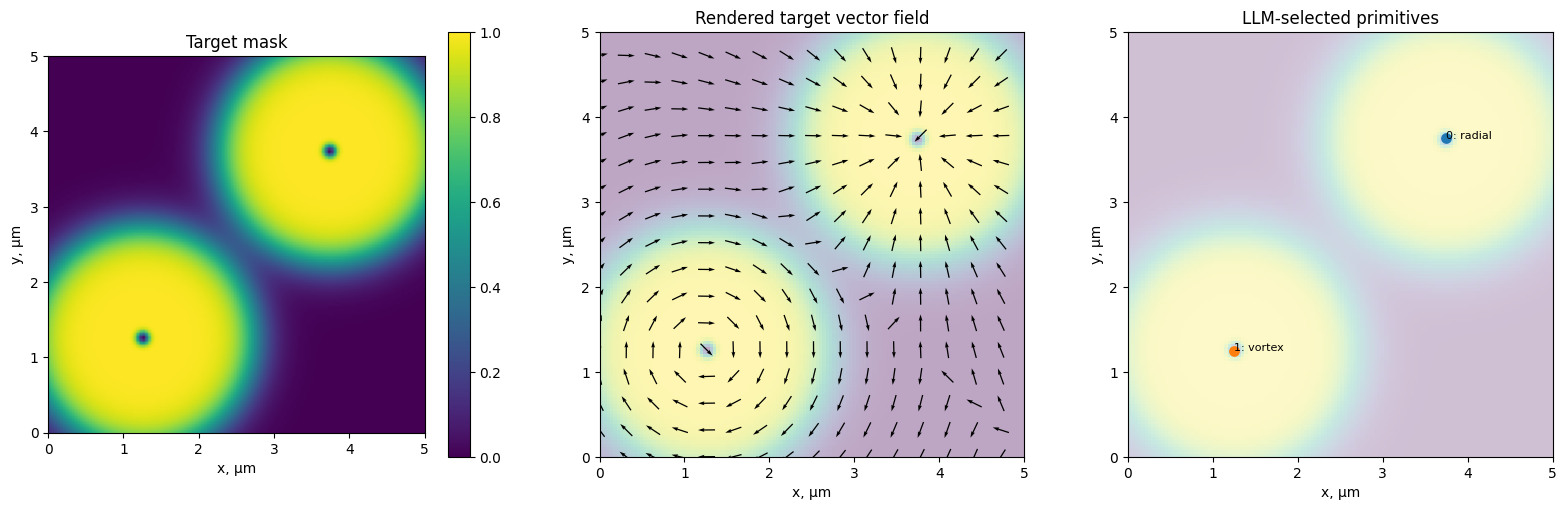

In [5]:
# Example: prompt -> target vector field (P_target, mask, program).

prompt = "Create a center-convergent pattern in the upper right and a clockwise vortex in the lower left."
P_target, mask, program = prompt_to_primitive_vector_field(prompt, visualize=True)

# 3. Predicting the writing trajectory (inverse design)

Given the target field, we trace streamlines that follow it and convert them into probe strokes `x(t), y(t)` with a per-point voltage `V(t)`. Because the writing model assumes `E_eff ~ V * t_hat`, a negative writing voltage reverses each stroke so the written field still points along the target.

In [6]:
#@title predictor
# Inverse design: trace streamlines of the target field and turn them into
# probe strokes x(t), y(t) with per-point voltage V(t), joined by voltage-off travel.

# ============================================================
# Target vector field -> lithography trajectory planner
# ============================================================
#
# Input:
#     P_target : np.ndarray, shape (ny, nx, 2)
#     mask     : optional np.ndarray, shape (ny, nx)
#
# Output:
#     trajectory : ProbeTrajectory
#     info       : dict with strokes, coverage, and parameters
#
# Main use:
#
#     planner = StreamlineTrajectoryPlanner(area_um=(5.0, 5.0))
#
#     trajectory, info = planner.plan(
#         P_target,
#         mask=mask,
#         voltage_sign=-1,
#         V_min_abs=4.0,
#         V_max_abs=10.0,
#     )
#
#     planner.plot_plan(P_target, mask, trajectory, info)
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Optional


# ============================================================
# 1. Trajectory container
# ============================================================

@dataclass
class ProbeTrajectory:
    """
    Full probe-writing program.

    x, y:
        Probe coordinates in microns.

    V:
        Voltage at each trajectory point.

    dt:
        Relative dwell time at each point.

    write_mask:
        True  = writing point, voltage ON.
        False = travel point, voltage OFF.

    stroke_id:
        Index of writing stroke.
        -1 means voltage-off travel.
    """

    x: np.ndarray
    y: np.ndarray
    V: np.ndarray
    dt: np.ndarray
    write_mask: np.ndarray
    stroke_id: np.ndarray

    @property
    def n_points(self):
        return len(self.x)

    def tangents(self, eps=1e-12):
        dx = np.gradient(self.x)
        dy = np.gradient(self.y)

        mag = np.sqrt(dx**2 + dy**2)

        tx = dx / (mag + eps)
        ty = dy / (mag + eps)

        return np.stack([tx, ty], axis=-1)

    def length(self, writing_only=True):
        dx = np.diff(self.x)
        dy = np.diff(self.y)
        ds = np.sqrt(dx**2 + dy**2)

        if writing_only:
            mask = self.write_mask[:-1] & self.write_mask[1:]
            return float(ds[mask].sum())

        return float(ds.sum())


# ============================================================
# 2. Helper functions
# ============================================================

def normalize_field(P, eps=1e-12):
    mag = np.linalg.norm(P, axis=-1, keepdims=True)
    return P / (mag + eps)


def make_xy_grid(shape, area_um):
    ny, nx = shape
    Lx, Ly = area_um

    xs = np.linspace(0, Lx, nx)
    ys = np.linspace(0, Ly, ny)

    return np.meshgrid(xs, ys)


def inside_area(x, y, area_um):
    Lx, Ly = area_um
    return (0 <= x <= Lx) and (0 <= y <= Ly)


def bilinear_interpolate_scalar(field, x, y, area_um):
    """
    Bilinear interpolation of scalar field at coordinate (x, y).
    """
    ny, nx = field.shape
    Lx, Ly = area_um

    if not inside_area(x, y, area_um):
        return 0.0

    px = x / Lx * (nx - 1)
    py = y / Ly * (ny - 1)

    x0 = int(np.floor(px))
    y0 = int(np.floor(py))

    x1 = min(x0 + 1, nx - 1)
    y1 = min(y0 + 1, ny - 1)

    dx = px - x0
    dy = py - y0

    v00 = field[y0, x0]
    v10 = field[y0, x1]
    v01 = field[y1, x0]
    v11 = field[y1, x1]

    v0 = (1 - dx) * v00 + dx * v10
    v1 = (1 - dx) * v01 + dx * v11

    return float((1 - dy) * v0 + dy * v1)


def bilinear_interpolate_vector(field, x, y, area_um):
    """
    Bilinear interpolation of vector field at coordinate (x, y).
    """
    ny, nx, _ = field.shape
    Lx, Ly = area_um

    if not inside_area(x, y, area_um):
        return None

    px = x / Lx * (nx - 1)
    py = y / Ly * (ny - 1)

    x0 = int(np.floor(px))
    y0 = int(np.floor(py))

    x1 = min(x0 + 1, nx - 1)
    y1 = min(y0 + 1, ny - 1)

    dx = px - x0
    dy = py - y0

    v00 = field[y0, x0]
    v10 = field[y0, x1]
    v01 = field[y1, x0]
    v11 = field[y1, x1]

    v0 = (1 - dx) * v00 + dx * v10
    v1 = (1 - dx) * v01 + dx * v11

    return (1 - dy) * v0 + dy * v1


def xy_to_index(x, y, shape, area_um):
    ny, nx = shape
    Lx, Ly = area_um

    ix = int(np.clip(np.round(x / Lx * (nx - 1)), 0, nx - 1))
    iy = int(np.clip(np.round(y / Ly * (ny - 1)), 0, ny - 1))

    return iy, ix


# ============================================================
# 3. Streamline trajectory planner
# ============================================================

class StreamlineTrajectoryPlanner:
    """
    Inverse-design trajectory planner.

    Idea:
        Target vector field
            -> trace streamlines
            -> keep strokes that cover new target area
            -> assign pointwise voltage
            -> connect strokes with voltage-off travel
            -> output x(t), y(t), V(t)
    """

    def __init__(
        self,
        area_um=(5.0, 5.0),
        seed_spacing_um=0.35,
        step_um=0.035,
        coverage_radius_um=0.10,
        min_mask_value=0.2,
        min_field_magnitude=0.05,
        min_points_per_stroke=20,
        min_new_fraction=0.25,
        max_strokes=80,
        max_steps_per_direction=1200,
        travel_step_um=0.06,
        random_seed=0,
    ):
        self.area_um = area_um
        self.seed_spacing_um = seed_spacing_um
        self.step_um = step_um
        self.coverage_radius_um = coverage_radius_um
        self.min_mask_value = min_mask_value
        self.min_field_magnitude = min_field_magnitude
        self.min_points_per_stroke = min_points_per_stroke
        self.min_new_fraction = min_new_fraction
        self.max_strokes = max_strokes
        self.max_steps_per_direction = max_steps_per_direction
        self.travel_step_um = travel_step_um
        self.random_seed = random_seed

    # --------------------------------------------------------
    # Field preparation
    # --------------------------------------------------------

    def prepare_field(self, P_target, mask=None):
        P_target = np.asarray(P_target, dtype=float)

        if P_target.ndim != 3 or P_target.shape[-1] != 2:
            raise ValueError("P_target must have shape (ny, nx, 2).")

        mag = np.linalg.norm(P_target, axis=-1)
        Pn = P_target / (mag[..., None] + 1e-12)

        if mask is None:
            mask = mag > self.min_field_magnitude
            mask = mask.astype(float)
        else:
            mask = np.asarray(mask, dtype=float)

        if mask.shape != P_target.shape[:2]:
            raise ValueError("mask must have shape (ny, nx).")

        return Pn, mag, mask

    # --------------------------------------------------------
    # Streamline tracing
    # --------------------------------------------------------

    def trace_one_direction(self, Pn, mask, seed_xy, direction=1):
        """
        Trace one half-streamline.

        direction=+1 follows the target field.
        direction=-1 follows opposite to the target field.
        """
        points = [np.asarray(seed_xy, dtype=float)]

        for step in range(self.max_steps_per_direction):
            x, y = points[-1]

            if not inside_area(x, y, self.area_um):
                break

            m = bilinear_interpolate_scalar(mask, x, y, self.area_um)

            if m < self.min_mask_value:
                break

            v = bilinear_interpolate_vector(Pn, x, y, self.area_um)

            if v is None:
                break

            vmag = np.linalg.norm(v)

            if vmag < self.min_field_magnitude:
                break

            tangent = direction * v / (vmag + 1e-12)

            new_point = points[-1] + self.step_um * tangent

            if not inside_area(new_point[0], new_point[1], self.area_um):
                break

            points.append(new_point)

            # Stop if we are returning to the seed, useful for vortex loops
            if step > 30:
                dist_to_seed = np.linalg.norm(new_point - seed_xy)

                if dist_to_seed < 1.5 * self.step_um:
                    break

        return np.asarray(points)

    def trace_full_streamline(self, Pn, mask, seed_xy):
        """
        Trace full streamline through seed.

        Returned path is ordered so that tangent approximately follows P_target.
        """
        forward = self.trace_one_direction(Pn, mask, seed_xy, direction=1)
        backward = self.trace_one_direction(Pn, mask, seed_xy, direction=-1)

        # If forward path is a closed loop, keep it directly
        if len(forward) > 40:
            if np.linalg.norm(forward[-1] - forward[0]) < 2.0 * self.step_um:
                return forward

        # Otherwise join backward and forward parts
        path = np.vstack([backward[::-1], forward[1:]])

        return path

    # --------------------------------------------------------
    # Coverage handling
    # --------------------------------------------------------

    def mark_coverage(self, coverage, path):
        """
        Mark pixels close to the written path as covered.
        """
        ny, nx = coverage.shape
        Lx, Ly = self.area_um

        rx_pix = max(1, int(np.ceil(self.coverage_radius_um / Lx * nx)))
        ry_pix = max(1, int(np.ceil(self.coverage_radius_um / Ly * ny)))

        for x, y in path:
            iy, ix = xy_to_index(x, y, coverage.shape, self.area_um)

            y0 = max(0, iy - ry_pix)
            y1 = min(ny, iy + ry_pix + 1)

            x0 = max(0, ix - rx_pix)
            x1 = min(nx, ix + rx_pix + 1)

            coverage[y0:y1, x0:x1] = True

    def path_new_fraction(self, coverage, path):
        """
        Fraction of path points that pass through previously uncovered pixels.
        """
        values = []

        for x, y in path:
            iy, ix = xy_to_index(x, y, coverage.shape, self.area_um)
            values.append(not coverage[iy, ix])

        if len(values) == 0:
            return 0.0

        return float(np.mean(values))

    # --------------------------------------------------------
    # Voltage assignment
    # --------------------------------------------------------

    def voltage_for_path(
        self,
        path,
        mag,
        voltage_sign=-1,
        V_min_abs=4.0,
        V_max_abs=10.0,
        mode="magnitude",
    ):
        """
        Assign pointwise voltage to one writing stroke.

        mode:
            "constant"  -> all points get V_max_abs.
            "magnitude" -> voltage follows local target-field magnitude.
        """
        n = len(path)

        if mode == "constant":
            return voltage_sign * V_max_abs * np.ones(n)

        mag_min = float(np.nanmin(mag))
        mag_max = float(np.nanmax(mag))

        if mag_max - mag_min < 1e-12:
            return voltage_sign * V_max_abs * np.ones(n)

        V = []

        for x, y in path:
            local_mag = bilinear_interpolate_scalar(mag, x, y, self.area_um)
            local_mag_norm = (local_mag - mag_min) / (mag_max - mag_min)
            local_mag_norm = float(np.clip(local_mag_norm, 0, 1))

            V_abs = V_min_abs + local_mag_norm * (V_max_abs - V_min_abs)
            V.append(voltage_sign * V_abs)

        return np.asarray(V)

    # --------------------------------------------------------
    # Stroke connection
    # --------------------------------------------------------

    def make_travel_segment(self, p0, p1):
        p0 = np.asarray(p0, dtype=float)
        p1 = np.asarray(p1, dtype=float)

        dist = np.linalg.norm(p1 - p0)
        n = max(2, int(np.ceil(dist / self.travel_step_um)))

        alpha = np.linspace(0, 1, n)
        path = (1 - alpha[:, None]) * p0 + alpha[:, None] * p1

        return path

    def assemble_trajectory(self, strokes, stroke_voltages):
        """
        Assemble strokes into a continuous trajectory.

        Travel between strokes is added automatically with V=0.
        """
        xs = []
        ys = []
        Vs = []
        dts = []
        write_mask = []
        stroke_ids = []

        previous_end = None

        for sid, (path, V_stroke) in enumerate(zip(strokes, stroke_voltages)):
            if len(path) < 2:
                continue

            if previous_end is not None:
                travel = self.make_travel_segment(previous_end, path[0])

                for p in travel[1:]:
                    xs.append(p[0])
                    ys.append(p[1])
                    Vs.append(0.0)
                    dts.append(1.0)
                    write_mask.append(False)
                    stroke_ids.append(-1)

            for p, v in zip(path, V_stroke):
                xs.append(p[0])
                ys.append(p[1])
                Vs.append(v)
                dts.append(1.0)
                write_mask.append(True)
                stroke_ids.append(sid)

            previous_end = path[-1]

        return ProbeTrajectory(
            x=np.asarray(xs),
            y=np.asarray(ys),
            V=np.asarray(Vs),
            dt=np.asarray(dts),
            write_mask=np.asarray(write_mask, dtype=bool),
            stroke_id=np.asarray(stroke_ids, dtype=int),
        )

    # --------------------------------------------------------
    # Main planner
    # --------------------------------------------------------

    def plan(
        self,
        P_target,
        mask=None,
        voltage_sign=-1,
        V_min_abs=4.0,
        V_max_abs=10.0,
        voltage_mode="magnitude",
        seed_order="random",
    ):
        """
        Main inverse-design method.

        Important convention:
            The simplified writing model assumes

                E_eff ~ V * t_hat

            where t_hat is the local direction of probe motion.

            If voltage_sign is negative, each streamline is reversed so that
            V * t_hat still aligns with the target vector field.
        """
        rng = np.random.default_rng(self.random_seed)

        Pn, mag, mask = self.prepare_field(P_target, mask=mask)

        ny, nx = mask.shape
        Lx, Ly = self.area_um

        coverage = np.zeros((ny, nx), dtype=bool)

        xs = np.arange(self.seed_spacing_um / 2, Lx, self.seed_spacing_um)
        ys = np.arange(self.seed_spacing_um / 2, Ly, self.seed_spacing_um)

        seeds = []

        for y in ys:
            for x in xs:
                m = bilinear_interpolate_scalar(mask, x, y, self.area_um)
                if m >= self.min_mask_value:
                    seeds.append((x, y))

        seeds = np.asarray(seeds, dtype=float)

        if len(seeds) == 0:
            raise RuntimeError("No valid seed points found. Check target mask or seed spacing.")

        if seed_order == "random":
            rng.shuffle(seeds)

        elif seed_order == "strongest":
            seed_strengths = np.array([
                bilinear_interpolate_scalar(mag, x, y, self.area_um)
                for x, y in seeds
            ])
            seeds = seeds[np.argsort(seed_strengths)[::-1]]

        strokes = []
        stroke_voltages = []

        for seed in seeds:
            iy, ix = xy_to_index(seed[0], seed[1], coverage.shape, self.area_um)

            if coverage[iy, ix]:
                continue

            path = self.trace_full_streamline(Pn, mask, seed)

            if len(path) < self.min_points_per_stroke:
                continue

            frac_new = self.path_new_fraction(coverage, path)

            if frac_new < self.min_new_fraction:
                continue

            # For E_eff = V * t_hat:
            # positive voltage -> move along target field.
            # negative voltage -> move opposite to target field.
            if voltage_sign < 0:
                path = path[::-1]

            V_stroke = self.voltage_for_path(
                path,
                mag=mag,
                voltage_sign=voltage_sign,
                V_min_abs=V_min_abs,
                V_max_abs=V_max_abs,
                mode=voltage_mode,
            )

            strokes.append(path)
            stroke_voltages.append(V_stroke)

            self.mark_coverage(coverage, path)

            if len(strokes) >= self.max_strokes:
                break

        trajectory = self.assemble_trajectory(strokes, stroke_voltages)

        info = {
            "strokes": strokes,
            "stroke_voltages": stroke_voltages,
            "coverage": coverage,
            "mask": mask,
            "field_magnitude": mag,
            "n_strokes": len(strokes),
            "writing_length_um": trajectory.length(writing_only=True),
            "total_length_um": trajectory.length(writing_only=False),
            "area_um": self.area_um,
        }

        return trajectory, info

    # --------------------------------------------------------
    # Visualization
    # --------------------------------------------------------

    def plot_plan(self, P_target, mask, trajectory, info=None, stride=8):
        """
        Visualize the target field and planned trajectory.
        """
        Pn = normalize_field(P_target)

        ny, nx, _ = P_target.shape
        X, Y = make_xy_grid((ny, nx), self.area_um)

        if mask is None:
            mask = np.linalg.norm(P_target, axis=-1)

        fig, axes = plt.subplots(2, 3, figsize=(16, 10))

        # Target mask
        ax = axes[0, 0]
        im = ax.imshow(
            mask,
            origin="lower",
            extent=[0, self.area_um[0], 0, self.area_um[1]],
            vmin=0,
            vmax=1,
        )
        ax.set_title("Target mask")
        fig.colorbar(im, ax=ax)

        # Target vector field
        ax = axes[0, 1]
        ax.imshow(
            mask,
            origin="lower",
            extent=[0, self.area_um[0], 0, self.area_um[1]],
            alpha=0.35,
            vmin=0,
            vmax=1,
        )
        ax.quiver(
            X[::stride, ::stride],
            Y[::stride, ::stride],
            Pn[::stride, ::stride, 0],
            Pn[::stride, ::stride, 1],
            pivot="mid",
            scale=25,
            width=0.003,
        )
        ax.set_title("Target vector field")

        # Planned writing strokes
        ax = axes[0, 2]
        ax.imshow(
            mask,
            origin="lower",
            extent=[0, self.area_um[0], 0, self.area_um[1]],
            alpha=0.25,
            vmin=0,
            vmax=1,
        )

        stroke_ids = trajectory.stroke_id

        for sid in np.unique(stroke_ids):
            if sid < 0:
                continue

            m = stroke_ids == sid
            ax.plot(
                trajectory.x[m],
                trajectory.y[m],
                linewidth=0.9,
                alpha=0.8,
            )

        ax.set_title("Writing strokes")

        # Full trajectory colored by voltage
        ax = axes[1, 0]
        sc = ax.scatter(
            trajectory.x,
            trajectory.y,
            c=trajectory.V,
            s=3,
        )
        ax.set_title("Full trajectory colored by voltage")
        fig.colorbar(sc, ax=ax, label="Voltage, V")

        # Voltage profile
        ax = axes[1, 1]
        ax.plot(trajectory.V, linewidth=1)
        ax.set_title("Voltage profile")
        ax.set_xlabel("Trajectory point")
        ax.set_ylabel("Voltage, V")

        # Coverage
        ax = axes[1, 2]
        if info is not None and "coverage" in info:
            coverage = info["coverage"]
            im = ax.imshow(
                coverage,
                origin="lower",
                extent=[0, self.area_um[0], 0, self.area_um[1]],
                vmin=0,
                vmax=1,
            )
            ax.set_title("Planned coverage")
            fig.colorbar(im, ax=ax)
        else:
            ax.axis("off")

        for ax in axes.ravel():
            if ax.has_data():
                ax.set_xlim(0, self.area_um[0])
                ax.set_ylim(0, self.area_um[1])
                ax.set_aspect("equal")
                ax.set_xlabel("x, µm")
                ax.set_ylabel("y, µm")

        plt.tight_layout()
        plt.show()

In [7]:
#@title Improved planner: better voltage assignment (constant/mask/edge) + cleaner plots.

# ============================================================
# Improved voltage assignment + plotting for StreamlineTrajectoryPlanner
# ============================================================

def local_mask_gradient(mask, area_um):
    """
    Estimate edge strength from the mask.
    Larger values appear near boundaries of the target region.
    """
    Lx, Ly = area_um
    ny, nx = mask.shape

    dx_um = Lx / max(nx - 1, 1)
    dy_um = Ly / max(ny - 1, 1)

    gy, gx = np.gradient(mask, dy_um, dx_um)
    g = np.sqrt(gx**2 + gy**2)

    if g.max() > 1e-12:
        g = g / g.max()

    return g


def clean_mask_simple(mask, threshold=0.35):
    """
    Simple mask cleanup.

    This only thresholds the LLM-generated soft mask.
    It does not remove connected components, but it removes weak halos.
    """
    return (mask > threshold).astype(float)


class ImprovedStreamlineTrajectoryPlanner(StreamlineTrajectoryPlanner):
    """
    Same streamline planner, but with better voltage assignment and plotting.
    """

    def voltage_for_path(
        self,
        path,
        mag,
        mask=None,
        voltage_sign=-1,
        V_min_abs=4.0,
        V_max_abs=10.0,
        mode="constant",
    ):
        """
        Assign pointwise voltage to one writing stroke.

        Modes
        -----
        constant:
            Same voltage everywhere during writing.

        magnitude:
            Voltage follows magnitude of P_target.
            Usually not very useful if P_target is normalized.

        mask:
            Voltage follows the target mask.
            Useful when mask is soft: lower voltage near soft edges.

        edge_boost:
            Voltage is higher near mask boundaries.
            Useful if you want stronger writing at feature edges.
        """

        n = len(path)

        if mode == "constant":
            return voltage_sign * V_max_abs * np.ones(n)

        if mode == "magnitude":
            scalar = mag

        elif mode == "mask":
            if mask is None:
                scalar = mag
            else:
                scalar = mask

        elif mode == "edge_boost":
            if mask is None:
                scalar = mag
            else:
                edge = local_mask_gradient(mask, self.area_um)
                scalar = 0.6 * mask + 0.4 * edge

        else:
            raise ValueError(
                "voltage mode must be 'constant', 'magnitude', 'mask', or 'edge_boost'"
            )

        s_min = float(np.nanmin(scalar))
        s_max = float(np.nanmax(scalar))

        if s_max - s_min < 1e-12:
            return voltage_sign * V_max_abs * np.ones(n)

        V = []

        for x, y in path:
            s = bilinear_interpolate_scalar(scalar, x, y, self.area_um)
            s_norm = (s - s_min) / (s_max - s_min)
            s_norm = float(np.clip(s_norm, 0, 1))

            V_abs = V_min_abs + s_norm * (V_max_abs - V_min_abs)
            V.append(voltage_sign * V_abs)

        return np.asarray(V)

    def plan(
        self,
        P_target,
        mask=None,
        voltage_sign=-1,
        V_min_abs=4.0,
        V_max_abs=10.0,
        voltage_mode="constant",
        seed_order="random",
        clean_mask=True,
        mask_threshold=0.35,
    ):
        """
        Main inverse-design method with improved voltage handling.
        """

        rng = np.random.default_rng(self.random_seed)

        Pn, mag, mask = self.prepare_field(P_target, mask=mask)

        if clean_mask:
            mask = clean_mask_simple(mask, threshold=mask_threshold)

        ny, nx = mask.shape
        Lx, Ly = self.area_um

        coverage = np.zeros((ny, nx), dtype=bool)

        xs = np.arange(self.seed_spacing_um / 2, Lx, self.seed_spacing_um)
        ys = np.arange(self.seed_spacing_um / 2, Ly, self.seed_spacing_um)

        seeds = []

        for y in ys:
            for x in xs:
                m = bilinear_interpolate_scalar(mask, x, y, self.area_um)
                if m >= self.min_mask_value:
                    seeds.append((x, y))

        seeds = np.asarray(seeds, dtype=float)

        if len(seeds) == 0:
            raise RuntimeError("No valid seed points found. Check mask or seed spacing.")

        if seed_order == "random":
            rng.shuffle(seeds)

        elif seed_order == "strongest":
            seed_strengths = np.array([
                bilinear_interpolate_scalar(mag, x, y, self.area_um)
                for x, y in seeds
            ])
            seeds = seeds[np.argsort(seed_strengths)[::-1]]

        strokes = []
        stroke_voltages = []

        for seed in seeds:
            iy, ix = xy_to_index(seed[0], seed[1], coverage.shape, self.area_um)

            if coverage[iy, ix]:
                continue

            path = self.trace_full_streamline(Pn, mask, seed)

            if len(path) < self.min_points_per_stroke:
                continue

            frac_new = self.path_new_fraction(coverage, path)

            if frac_new < self.min_new_fraction:
                continue

            # Convention:
            # E_eff ~ V * t_hat.
            # If V is negative, reverse path so written field follows target.
            if voltage_sign < 0:
                path = path[::-1]

            V_stroke = self.voltage_for_path(
                path,
                mag=mag,
                mask=mask,
                voltage_sign=voltage_sign,
                V_min_abs=V_min_abs,
                V_max_abs=V_max_abs,
                mode=voltage_mode,
            )

            strokes.append(path)
            stroke_voltages.append(V_stroke)

            self.mark_coverage(coverage, path)

            if len(strokes) >= self.max_strokes:
                break

        trajectory = self.assemble_trajectory(strokes, stroke_voltages)

        info = {
            "strokes": strokes,
            "stroke_voltages": stroke_voltages,
            "coverage": coverage,
            "mask": mask,
            "field_magnitude": mag,
            "n_strokes": len(strokes),
            "writing_length_um": trajectory.length(writing_only=True),
            "total_length_um": trajectory.length(writing_only=False),
            "area_um": self.area_um,
            "voltage_mode": voltage_mode,
        }

        return trajectory, info

    def plot_plan(self, P_target, mask, trajectory, info=None, stride=8):
        """
        Improved visualization.

        Important fix:
        The voltage-profile plot is not forced to x/y limits in microns.
        """

        Pn = normalize_field(P_target)

        ny, nx, _ = P_target.shape
        X, Y = make_xy_grid((ny, nx), self.area_um)

        if mask is None:
            mask = np.linalg.norm(P_target, axis=-1)

        if info is not None and "mask" in info:
            plot_mask = info["mask"]
        else:
            plot_mask = mask

        fig, axes = plt.subplots(2, 3, figsize=(16, 10))

        # ----------------------------------------------------
        # Target mask
        # ----------------------------------------------------
        ax = axes[0, 0]
        im = ax.imshow(
            plot_mask,
            origin="lower",
            extent=[0, self.area_um[0], 0, self.area_um[1]],
            vmin=0,
            vmax=1,
        )
        ax.set_title("Target mask used by planner")
        ax.set_xlabel("x, µm")
        ax.set_ylabel("y, µm")
        ax.set_aspect("equal")
        fig.colorbar(im, ax=ax)

        # ----------------------------------------------------
        # Target vector field
        # ----------------------------------------------------
        ax = axes[0, 1]
        ax.imshow(
            plot_mask,
            origin="lower",
            extent=[0, self.area_um[0], 0, self.area_um[1]],
            alpha=0.35,
            vmin=0,
            vmax=1,
        )
        ax.quiver(
            X[::stride, ::stride],
            Y[::stride, ::stride],
            Pn[::stride, ::stride, 0],
            Pn[::stride, ::stride, 1],
            pivot="mid",
            scale=25,
            width=0.003,
        )
        ax.set_title("Target vector field")
        ax.set_xlabel("x, µm")
        ax.set_ylabel("y, µm")
        ax.set_xlim(0, self.area_um[0])
        ax.set_ylim(0, self.area_um[1])
        ax.set_aspect("equal")

        # ----------------------------------------------------
        # Writing strokes
        # ----------------------------------------------------
        ax = axes[0, 2]
        ax.imshow(
            plot_mask,
            origin="lower",
            extent=[0, self.area_um[0], 0, self.area_um[1]],
            alpha=0.25,
            vmin=0,
            vmax=1,
        )

        for sid in np.unique(trajectory.stroke_id):
            if sid < 0:
                continue

            m = trajectory.stroke_id == sid
            ax.plot(
                trajectory.x[m],
                trajectory.y[m],
                linewidth=0.9,
                alpha=0.85,
            )

        ax.set_title("Writing strokes")
        ax.set_xlabel("x, µm")
        ax.set_ylabel("y, µm")
        ax.set_xlim(0, self.area_um[0])
        ax.set_ylim(0, self.area_um[1])
        ax.set_aspect("equal")

        # ----------------------------------------------------
        # Full trajectory colored by voltage
        # ----------------------------------------------------
        ax = axes[1, 0]

        write = trajectory.write_mask
        travel = ~trajectory.write_mask

        if np.any(travel):
            ax.plot(
                trajectory.x[travel],
                trajectory.y[travel],
                linewidth=0.5,
                alpha=0.35,
                label="travel, V=0",
            )

        sc = ax.scatter(
            trajectory.x[write],
            trajectory.y[write],
            c=trajectory.V[write],
            s=4,
        )

        ax.set_title("Writing trajectory colored by voltage")
        ax.set_xlabel("x, µm")
        ax.set_ylabel("y, µm")
        ax.set_xlim(0, self.area_um[0])
        ax.set_ylim(0, self.area_um[1])
        ax.set_aspect("equal")
        fig.colorbar(sc, ax=ax, label="Voltage, V")

        # ----------------------------------------------------
        # Voltage profile -- fixed
        # ----------------------------------------------------
        ax = axes[1, 1]
        ax.plot(trajectory.V, linewidth=1.0)
        ax.axhline(0, linewidth=0.8)
        ax.set_title("Voltage profile")
        ax.set_xlabel("Trajectory point")
        ax.set_ylabel("Voltage, V")

        ymin = min(np.min(trajectory.V) - 1.0, -1.0)
        ymax = max(np.max(trajectory.V) + 1.0, 1.0)
        ax.set_ylim(ymin, ymax)

        # ----------------------------------------------------
        # Coverage
        # ----------------------------------------------------
        ax = axes[1, 2]
        if info is not None and "coverage" in info:
            coverage = info["coverage"].astype(float)
            im = ax.imshow(
                coverage,
                origin="lower",
                extent=[0, self.area_um[0], 0, self.area_um[1]],
                vmin=0,
                vmax=1,
            )
            ax.set_title("Planned coverage")
            fig.colorbar(im, ax=ax)
        else:
            ax.axis("off")

        ax.set_xlabel("x, µm")
        ax.set_ylabel("y, µm")
        ax.set_xlim(0, self.area_um[0])
        ax.set_ylim(0, self.area_um[1])
        ax.set_aspect("equal")

        plt.tight_layout()
        plt.show()

Number of strokes: 32
Trajectory points: 7756
Writing length: 165.45 µm
Total length: 232.51 µm
Voltage range: -9.00 to 0.00 V


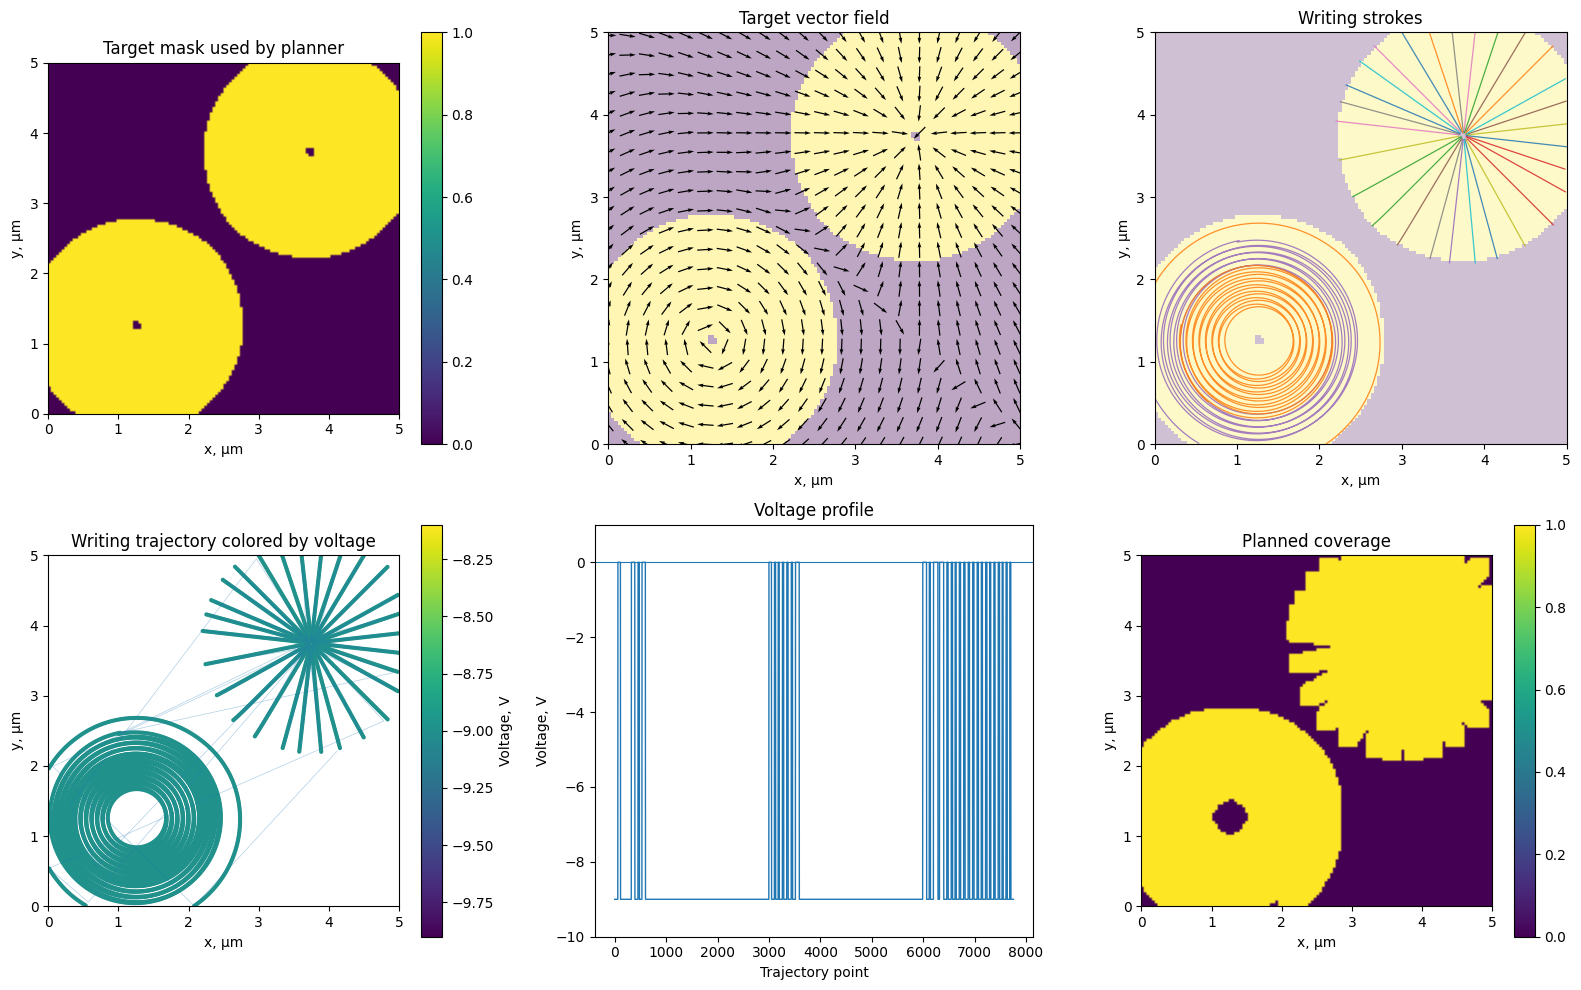

In [8]:
# Example: target field -> predicted writing trajectory.

area_um = (program.width_um, program.height_um) if "program" in globals() else (5.0, 5.0)

planner = ImprovedStreamlineTrajectoryPlanner(
    area_um=area_um,
    seed_spacing_um=0.25,
    step_um=0.025,
    coverage_radius_um=0.08,
    min_mask_value=0.5,
    min_points_per_stroke=20,
    min_new_fraction=0.20,
    max_strokes=120,
    random_seed=1,
)

trajectory, info = planner.plan(
    P_target,
    mask=mask,
    voltage_sign=-1,
    V_min_abs=5.0,
    V_max_abs=9.0,
    voltage_mode="constant",   # start with this
    clean_mask=True,
    mask_threshold=0.45,
)

print("Number of strokes:", info["n_strokes"])
print("Trajectory points:", trajectory.n_points)
print("Writing length:", f"{info['writing_length_um']:.2f} µm")
print("Total length:", f"{info['total_length_um']:.2f} µm")
print("Voltage range:", f"{trajectory.V.min():.2f} to {trajectory.V.max():.2f} V")

planner.plot_plan(P_target, mask, trajectory, info, stride=6)

# 4. Forward simulation and comparison with the target (GT)

The predicted trajectory is run through the minimal forward simulator (moving tip -> accumulated dose -> switched polarization), and the simulated pattern is compared with the target field using alignment, angular-error and coverage metrics.

In [9]:
#@title Forward simulator: trajectory x(t),y(t),V(t) -> field dose -> switched polarization.
# This is the minimal physical model used to PREDICT what a trajectory actually writes.

import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from typing import Optional, Literal


# ===== Simulation grid =====
@dataclass
class Grid2D:
    width_um: float = 5.0
    height_um: float = 5.0
    nx: int = 128
    ny: int = 128

    def __post_init__(self):
        self.xs = np.linspace(0, self.width_um, self.nx)
        self.ys = np.linspace(0, self.height_um, self.ny)
        self.X, self.Y = np.meshgrid(self.xs, self.ys)

    def inside(self, x, y):
        return 0 <= x <= self.width_um and 0 <= y <= self.height_um


# ===== Effective moving-tip writing field (E_eff ~ V * t_hat * Gaussian) =====
@dataclass
class TipFieldModel:
    """
    Minimal moving-tip effective field model.

    The core assumption is:

        E_eff(x, y, t) ~ V(t) * t_hat(t) * K_sigma(x - x_tip, y - y_tip)

    where t_hat is the local probe travel direction.
    """
    mode: Literal["trailing", "hybrid"] = "trailing"

    sigma_um: float = 0.06
    sigma_per_abs_volt_um: float = 0.006

    amplitude_scale: float = 1.0
    epsilon_r: float = 80.0

    hybrid_trailing_weight: float = 0.85
    radial_softening_um: float = 0.04

    def writing_width(self, V):
        return self.sigma_um + self.sigma_per_abs_volt_um * abs(V)

    def kernel(self, grid, x0, y0, V):
        sigma = self.writing_width(V)
        r2 = (grid.X - x0)**2 + (grid.Y - y0)**2
        return np.exp(-0.5 * r2 / sigma**2)

    def field(self, grid, x0, y0, V, t_hat):
        K = self.kernel(grid, x0, y0, V)

        amp = self.amplitude_scale * V / self.epsilon_r

        tx, ty = t_hat
        norm = np.sqrt(tx**2 + ty**2) + 1e-12
        tx, ty = tx / norm, ty / norm

        if self.mode == "trailing":
            Ex = amp * tx * K
            Ey = amp * ty * K
            return Ex, Ey

        if self.mode == "hybrid":
            dx = grid.X - x0
            dy = grid.Y - y0
            r = np.sqrt(dx**2 + dy**2 + self.radial_softening_um**2)

            rx = dx / r
            ry = dy / r

            w = self.hybrid_trailing_weight

            dir_x = w * tx + (1 - w) * rx
            dir_y = w * ty + (1 - w) * ry

            dir_norm = np.sqrt(dir_x**2 + dir_y**2) + 1e-12

            Ex = amp * dir_x / dir_norm * K
            Ey = amp * dir_y / dir_norm * K

            return Ex, Ey

        raise ValueError(f"Unknown mode: {self.mode}")


# ===== Minimal ferroelectric switching (accumulated dose -> polarization) =====
@dataclass
class MinimalFerroelectricModel:
    coercive_dose: float = 0.012
    sharpness: float = 6.0
    p_saturation: float = 1.0

    def polarization_from_dose(self, dose, initial_P=None):
        dose_mag = np.linalg.norm(dose, axis=-1)
        dose_dir = dose / (dose_mag[..., None] + 1e-12)

        x = (dose_mag - self.coercive_dose) / self.coercive_dose
        switch_fraction = 1 / (1 + np.exp(-self.sharpness * x))

        if initial_P is None:
            initial_P = np.zeros_like(dose)

        P = (1 - switch_fraction[..., None]) * initial_P
        P += switch_fraction[..., None] * self.p_saturation * dose_dir

        return P, switch_fraction


# ===== Moving-tip simulator (returns dose, polarization, switch_fraction) =====
@dataclass
class MovingTipSimulator:
    grid: Grid2D
    tip_model: TipFieldModel = field(default_factory=TipFieldModel)
    sample_model: MinimalFerroelectricModel = field(default_factory=MinimalFerroelectricModel)
    initial_P: Optional[np.ndarray] = None

    def run(self, trajectory):
        dose = np.zeros((self.grid.ny, self.grid.nx, 2), dtype=float)
        tangents = trajectory.tangents()

        for i in range(trajectory.n_points):
            if not trajectory.write_mask[i]:
                continue

            x0 = trajectory.x[i]
            y0 = trajectory.y[i]
            V0 = trajectory.V[i]

            if not self.grid.inside(x0, y0):
                continue

            if abs(V0) < 1e-12:
                continue

            Ex, Ey = self.tip_model.field(
                self.grid,
                x0=x0,
                y0=y0,
                V=V0,
                t_hat=tangents[i],
            )

            dose[..., 0] += Ex * trajectory.dt[i]
            dose[..., 1] += Ey * trajectory.dt[i]

        P, switch_fraction = self.sample_model.polarization_from_dose(
            dose,
            initial_P=self.initial_P,
        )

        return {
            "dose": dose,
            "polarization": P,
            "switch_fraction": switch_fraction,
            "trajectory": trajectory,
        }

In [11]:
#@title Metrics + plots that compare simulated polarization against the target field.

# ============================================================
# Final step: apply trajectory to simulator and compare to target
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


def normalize_vectors(P, eps=1e-12):
    mag = np.linalg.norm(P, axis=-1, keepdims=True)
    return P / (mag + eps)


def compare_target_and_simulation(
    P_target,
    P_sim,
    switch_fraction,
    target_mask=None,
    switch_threshold=0.5,
    target_threshold=0.5,
):
    """
    Compare target vector field and simulated written polarization.

    Parameters
    ----------
    P_target : array, shape (ny, nx, 2)
        Desired target vector field.

    P_sim : array, shape (ny, nx, 2)
        Simulated polarization field after applying trajectory.

    switch_fraction : array, shape (ny, nx)
        Switching fraction from the simulator.

    target_mask : array, shape (ny, nx), optional
        Region where the target should be written.

    Returns
    -------
    metrics : dict
        Quantitative comparison metrics.

    maps : dict
        Pixel-wise comparison maps.
    """

    if target_mask is None:
        target_mask = np.linalg.norm(P_target, axis=-1)

    target_region = target_mask > target_threshold
    switched_region = switch_fraction > switch_threshold

    P_target_n = normalize_vectors(P_target)
    P_sim_n = normalize_vectors(P_sim)

    alignment_map = np.sum(P_target_n * P_sim_n, axis=-1)
    alignment_map = np.clip(alignment_map, -1, 1)

    angular_error_map = np.rad2deg(np.arccos(alignment_map))

    # Compare only inside the desired target region
    if np.sum(target_region) > 0:
        mean_alignment_target = float(np.mean(alignment_map[target_region]))
        mean_angular_error_target = float(np.mean(angular_error_map[target_region]))
        target_coverage = float(np.mean(switched_region[target_region]))
    else:
        mean_alignment_target = np.nan
        mean_angular_error_target = np.nan
        target_coverage = np.nan

    # Compare only where the simulator actually switched
    valid_written = target_region & switched_region

    if np.sum(valid_written) > 0:
        mean_alignment_written = float(np.mean(alignment_map[valid_written]))
        mean_angular_error_written = float(np.mean(angular_error_map[valid_written]))
    else:
        mean_alignment_written = np.nan
        mean_angular_error_written = np.nan

    # Penalize writing outside the desired region
    outside_target = ~target_region

    if np.sum(outside_target) > 0:
        extra_switching = float(np.mean(switched_region[outside_target]))
    else:
        extra_switching = 0.0

    # Simple combined score
    # Good: high alignment and high coverage
    # Bad: writing outside the target
    score = (
        mean_alignment_target * target_coverage
        - 0.5 * extra_switching
    )

    metrics = {
        "score": score,
        "mean_alignment_target": mean_alignment_target,
        "mean_alignment_written": mean_alignment_written,
        "mean_angular_error_target_deg": mean_angular_error_target,
        "mean_angular_error_written_deg": mean_angular_error_written,
        "target_coverage": target_coverage,
        "extra_switching": extra_switching,
    }

    maps = {
        "target_region": target_region,
        "switched_region": switched_region,
        "alignment_map": alignment_map,
        "angular_error_map": angular_error_map,
    }

    return metrics, maps


def plot_simulation_comparison(
    P_target,
    P_sim,
    switch_fraction,
    target_mask,
    trajectory=None,
    metrics=None,
    area_um=(5.0, 5.0),
    stride=8,
):
    """
    Visualize target, trajectory, simulated result, and agreement.
    """

    ny, nx, _ = P_target.shape
    Lx, Ly = area_um

    xs = np.linspace(0, Lx, nx)
    ys = np.linspace(0, Ly, ny)
    X, Y = np.meshgrid(xs, ys)

    P_target_n = normalize_vectors(P_target)
    P_sim_n = normalize_vectors(P_sim)

    metrics_tmp, maps = compare_target_and_simulation(
        P_target,
        P_sim,
        switch_fraction,
        target_mask=target_mask,
    )

    if metrics is None:
        metrics = metrics_tmp

    alignment_map = maps["alignment_map"]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    # --------------------------------------------------------
    # Target vector field
    # --------------------------------------------------------
    ax = axes[0, 0]
    ax.imshow(
        target_mask,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        alpha=0.35,
        vmin=0,
        vmax=1,
    )
    ax.quiver(
        X[::stride, ::stride],
        Y[::stride, ::stride],
        P_target_n[::stride, ::stride, 0],
        P_target_n[::stride, ::stride, 1],
        pivot="mid",
        scale=25,
        width=0.003,
    )
    ax.set_title("Target vector field")

    # --------------------------------------------------------
    # Planned trajectory
    # --------------------------------------------------------
    ax = axes[0, 1]
    ax.imshow(
        target_mask,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        alpha=0.25,
        vmin=0,
        vmax=1,
    )

    if trajectory is not None:
        write = trajectory.write_mask

        ax.plot(
            trajectory.x[~write],
            trajectory.y[~write],
            linewidth=0.5,
            alpha=0.25,
            label="travel, V=0",
        )

        sc = ax.scatter(
            trajectory.x[write],
            trajectory.y[write],
            c=trajectory.V[write],
            s=4,
        )
        fig.colorbar(sc, ax=ax, label="Voltage, V")

    ax.set_title("Predicted writing trajectory")

    # --------------------------------------------------------
    # Switching fraction
    # --------------------------------------------------------
    ax = axes[0, 2]
    im = ax.imshow(
        switch_fraction,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        vmin=0,
        vmax=1,
    )
    ax.set_title("Simulated switching fraction")
    fig.colorbar(im, ax=ax)

    # --------------------------------------------------------
    # Simulated vector field
    # --------------------------------------------------------
    ax = axes[1, 0]
    ax.imshow(
        switch_fraction,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        alpha=0.35,
        vmin=0,
        vmax=1,
    )
    ax.quiver(
        X[::stride, ::stride],
        Y[::stride, ::stride],
        P_sim_n[::stride, ::stride, 0],
        P_sim_n[::stride, ::stride, 1],
        pivot="mid",
        scale=25,
        width=0.003,
    )
    ax.set_title("Simulated written vector field")

    # --------------------------------------------------------
    # Alignment map
    # --------------------------------------------------------
    ax = axes[1, 1]
    im = ax.imshow(
        alignment_map,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        vmin=-1,
        vmax=1,
    )
    ax.set_title("Target–simulation alignment")
    fig.colorbar(im, ax=ax, label="dot product")

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    ax = axes[1, 2]
    ax.axis("off")

    text = (
        f"Score: {metrics['score']:.3f}\n\n"
        f"Mean alignment in target:\n"
        f"{metrics['mean_alignment_target']:.3f}\n\n"
        f"Mean alignment where written:\n"
        f"{metrics['mean_alignment_written']:.3f}\n\n"
        f"Angular error in target:\n"
        f"{metrics['mean_angular_error_target_deg']:.1f}°\n\n"
        f"Target coverage:\n"
        f"{metrics['target_coverage']:.3f}\n\n"
        f"Extra switching outside target:\n"
        f"{metrics['extra_switching']:.3f}"
    )

    ax.text(
        0.05,
        0.95,
        text,
        va="top",
        ha="left",
        fontsize=12,
        family="monospace",
    )

    for ax in axes.ravel():
        if ax.has_data():
            ax.set_xlim(0, Lx)
            ax.set_ylim(0, Ly)
            ax.set_aspect("equal")
            ax.set_xlabel("x, µm")
            ax.set_ylabel("y, µm")

    plt.tight_layout()
    plt.show()


def run_trajectory_and_compare(
    simulator,
    trajectory,
    P_target,
    target_mask,
    area_um=(5.0, 5.0),
    stride=8,
):
    """
    Complete final evaluation step.

    Applies trajectory to simulator, compares simulated result to target,
    and visualizes the result.
    """

    result = simulator.run(trajectory)

    # Works with the simulator dictionary used earlier
    P_sim = result["polarization"]
    switch_fraction = result["switch_fraction"]

    metrics, maps = compare_target_and_simulation(
        P_target=P_target,
        P_sim=P_sim,
        switch_fraction=switch_fraction,
        target_mask=target_mask,
    )

    print("=== Trajectory evaluation ===")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")

    plot_simulation_comparison(
        P_target=P_target,
        P_sim=P_sim,
        switch_fraction=switch_fraction,
        target_mask=target_mask,
        trajectory=trajectory,
        metrics=metrics,
        area_um=area_um,
        stride=stride,
    )

    return result, metrics, maps

=== Trajectory evaluation ===
score: 0.8673
mean_alignment_target: 0.9997
mean_alignment_written: 0.9997
mean_angular_error_target_deg: 0.6921
mean_angular_error_written_deg: 0.6921
target_coverage: 1.0000
extra_switching: 0.2648


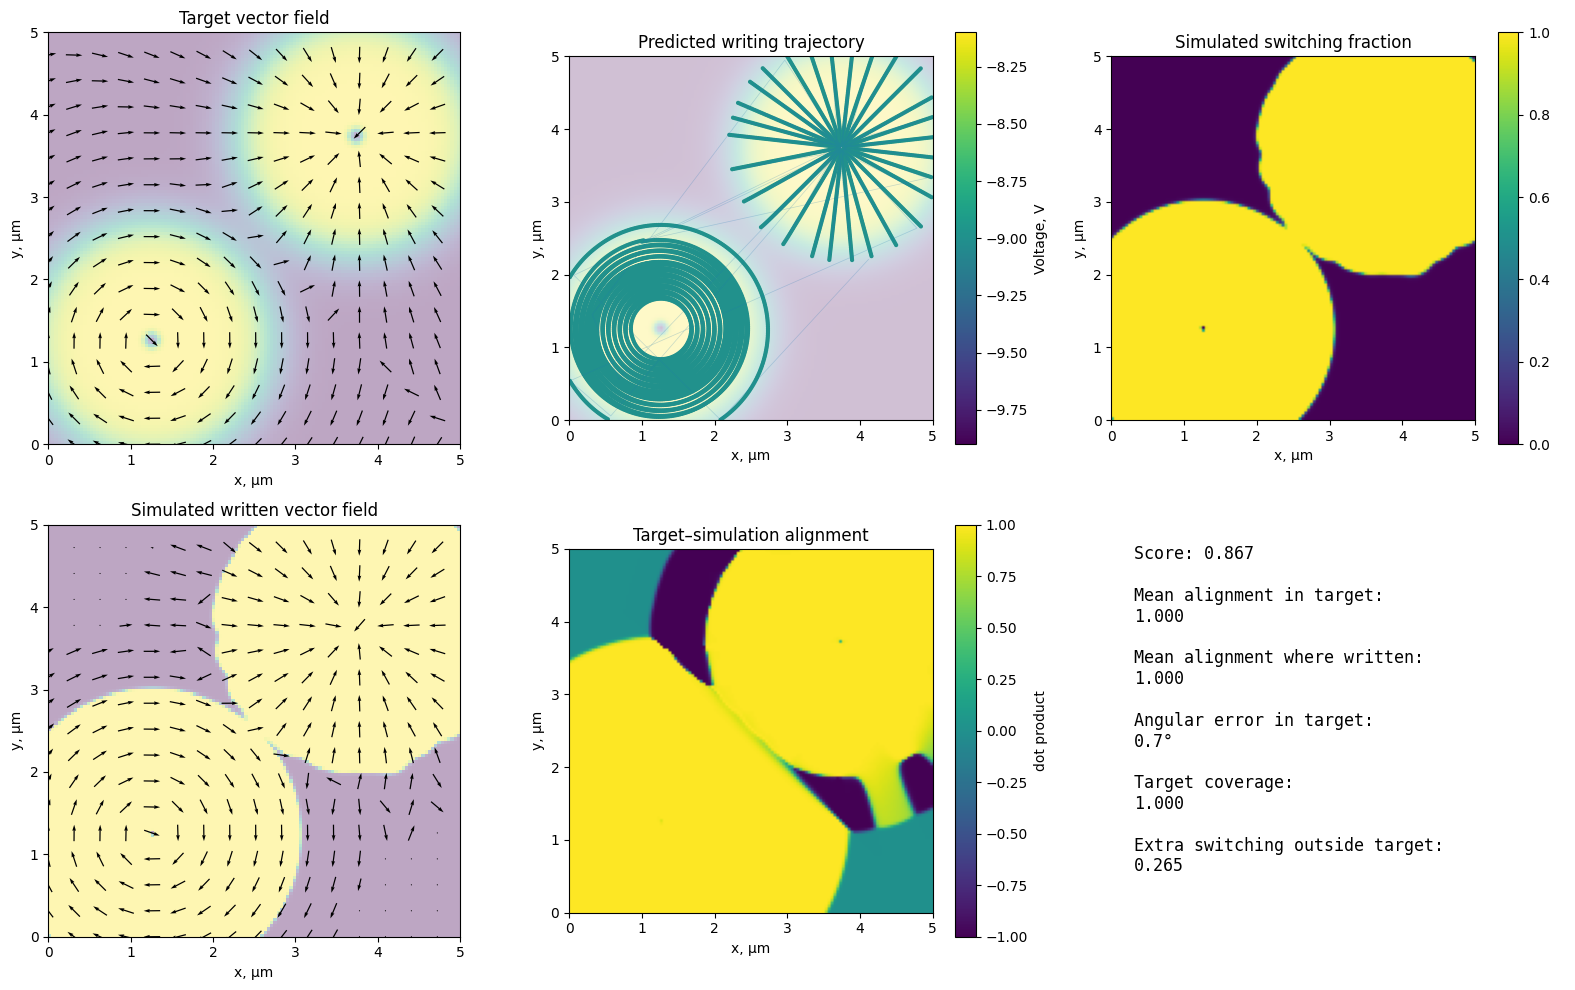

In [12]:
# Build simulator, run the predicted trajectory, and compare with the target.

# Area from the LLM program if available
area_um = (program.width_um, program.height_um) if "program" in globals() else (5.0, 5.0)

# Build simulator
grid = Grid2D(
    width_um=area_um[0],
    height_um=area_um[1],
    nx=P_target.shape[1],
    ny=P_target.shape[0],
)

tip_model = TipFieldModel(
    mode="trailing",
    sigma_um=0.06,
    sigma_per_abs_volt_um=0.006,
    epsilon_r=80.0,
)

sample_model = MinimalFerroelectricModel(
    coercive_dose=0.012,
    sharpness=6.0,
)

simulator = MovingTipSimulator(
    grid=grid,
    tip_model=tip_model,
    sample_model=sample_model,
)

# Run final evaluation
result, metrics, maps = run_trajectory_and_compare(
    simulator=simulator,
    trajectory=trajectory,
    P_target=P_target,
    target_mask=mask,
    area_um=area_um,
    stride=8,
)